# 📊 Analyse Statistique — Passoires Thermiques

---
## ⚙️ 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway, spearmanr, kruskal
import warnings
import os

warnings.filterwarnings('ignore')

# ── Style graphiques ──────────────────────────────────────────
plt.rcParams['figure.figsize']    = (13, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titlesize']    = 13
plt.rcParams['axes.titleweight']  = 'bold'
sns.set_palette('Set2')

C = {
    'red':    '#E74C3C',
    'blue':   '#2E86C1',
    'green':  '#27AE60',
    'orange': '#F39C12',
    'purple': '#8E44AD',
    'gray':   '#95A5A6',
    'dark':   '#2C3E50',
}

OUTPUT_DIR = 'outputs/stats'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('✅ Imports OK')
print(f'📁 Graphiques sauvegardés dans : {OUTPUT_DIR}/')

✅ Imports OK
📁 Graphiques sauvegardés dans : outputs/stats/


---
## 1️⃣ Chargement du dataset consolidé

In [2]:
# Chargement depuis 03_nettoyage_fusion.py
df = pd.read_csv('data/processed/dataset_consolide.csv',
                 dtype={'CODGEO': str}, low_memory=False)

# Convertir colonnes numériques
cols_num = [
    'NB_DPE_TOTAL', 'NB_PASSOIRES', 'TAUX_PASSOIRES',
    'SURFACE_MOY', 'CONSO_ENERGIE_MOY', 'ANNEE_CONSTRUCTION_MOY',
    'POPULATION', 'REVENU_MEDIAN', 'TAUX_PAUVRETE',
    'NB_LOGEMENTS', 'PASSOIRES_POUR_1000_HAB', 'SCORE_PRIORITE'
]
for col in cols_num:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(' Dataset consolidé chargé')
print(f'   {len(df):,} communes × {df.shape[1]} colonnes')
print(f'   Régions : {list(df["REGION"].unique())}')
print(f'   Départements : {df["DEP"].nunique()} départements')
display(df.head(3))

 Dataset consolidé chargé
   651 communes × 34 colonnes
   Régions : ['Hauts-de-France', 'Bretagne', 'Île-de-France']
   Départements : 15 départements


,CODGEO,NOM_COMMUNE,DEP,REGION,REGION_CODE,NB_DPE_TOTAL,NB_PASSOIRES,TAUX_PASSOIRES,NB_CLASSE_A,NB_CLASSE_B,...,NB_LOGEMENTS,NB_RP,NB_LOGVAC,PASSOIRES_POUR_1000_HAB,TAUX_COUVERTURE_DPE,RATIO_PASSOIRES_RP,TAUX_VACANCE,SCORE_PRIORITE,CATEGORIE_PRIORITE,RANG_PRIORITE
0,02019,Annois,2.0,Hauts-de-France,32,6,4,66.67,1,0,...,345.0,274.0,48.0,11.46,1.74,1.46,13.91,0.5383,Moyenne,474
1,02025,Artemps,2.0,Hauts-de-France,32,5,3,60.00,0,0,...,3940.0,3224.0,302.0,8.31,0.13,0.09,7.66,0.4918,Moyenne,674
2,02029,Attilly,2.0,Hauts-de-France,32,5,2,40.00,0,0,...,1370.0,1026.0,152.0,5.93,0.36,0.19,11.09,0.3696,Moyenne,1605


---
## 2️⃣ Statistiques descriptives globales

In [3]:
print(' STATISTIQUES DESCRIPTIVES GLOBALES')
print('='*55)

vars_desc = {
    'TAUX_PASSOIRES':          'Taux passoires (%)',
    'REVENU_MEDIAN':           'Revenu médian (€/an)',
    'TAUX_PAUVRETE':           'Taux pauvreté (%)',
    'POPULATION':              'Population',
    'SURFACE_MOY':             'Surface moyenne (m²)',
    'CONSO_ENERGIE_MOY':       'Consommation énergie (kWh/m²/an)',
    'ANNEE_CONSTRUCTION_MOY':  'Année construction moyenne',
    'PASSOIRES_POUR_1000_HAB': 'Passoires / 1000 hab',
    'SCORE_PRIORITE':          'Score priorité (0→1)',
}

rows = []
for col, label in vars_desc.items():
    if col not in df.columns:
        continue
    s = df[col].dropna()
    rows.append({
        'Variable':   label,
        'N':          len(s),
        'Moyenne':    round(s.mean(), 2),
        'Médiane':    round(s.median(), 2),
        'Écart-type': round(s.std(), 2),
        'Min':        round(s.min(), 2),
        'Max':        round(s.max(), 2),
        'Q25':        round(s.quantile(0.25), 2),
        'Q75':        round(s.quantile(0.75), 2),
    })

df_desc = pd.DataFrame(rows)
display(df_desc.style
    .background_gradient(subset=['Moyenne'], cmap='Blues')
    .format({'Moyenne': '{:.2f}', 'Médiane': '{:.2f}',
             'Écart-type': '{:.2f}', 'N': '{:,}'}))

df_desc.to_csv(f'{OUTPUT_DIR}/stats_descriptives.csv', index=False, encoding='utf-8')
print(f'\n Statistiques descriptives → {OUTPUT_DIR}/stats_descriptives.csv')

 STATISTIQUES DESCRIPTIVES GLOBALES


,Variable,N,Moyenne,Médiane,Écart-type,Min,Max,Q25,Q75
0,Taux passoires (%),651,30.68,33.33,19.79,0.000000,100.000000,20.000000,40.000000
1,Revenu médian (€/an),491,20008.43,19777.00,3805.17,11520.000000,40577.000000,17496.500000,22299.500000
2,Taux pauvreté (%),491,23.78,23.90,5.16,3.000000,37.900000,20.700000,27.200000
3,Population,491,3191.31,836.00,13889.77,13.000000,230890.000000,376.000000,2294.500000
4,Surface moyenne (m²),651,75.52,73.70,17.25,40.800000,140.200000,63.000000,85.800000
5,Consommation énergie (kWh/m²/an),651,374.88,375.00,75.52,153.200000,611.800000,321.850000,431.050000
6,Année construction moyenne,651,1974.88,1975.40,10.22,1940.400000,2004.000000,1968.000000,1982.200000
7,Passoires / 1000 hab,491,4.53,1.58,9.65,0.000000,105.260000,0.430000,4.500000
8,Score priorité (0→1),491,0.38,0.37,0.10,0.000000,0.690000,0.310000,0.430000



 Statistiques descriptives → outputs/stats/stats_descriptives.csv


---
## 3️⃣ Test ANOVA — Différences entre régions

 TEST ANOVA — Les taux de passoires diffèrent-ils significativement entre régions ?

   Hypothèses :
   H0 : Les moyennes de taux de passoires sont identiques dans les 3 régions
   H1 : Au moins une région a un taux significativement différent (α = 0.05)

   ANOVA paramétrique :
   F-statistique : 15.8194
   p-value       : 0.000000
   Conclusion    :  H1 acceptée — différences significatives (p < 0.05)

   Kruskal-Wallis (non paramétrique) :
   H-statistique : 25.7886
   p-value       : 0.000003
   Conclusion    :  Différences significatives confirmées

   Statistiques par région :


,N,Moyenne,Mediane,EcartType,Min,Max
REGION,,,,,,
Bretagne,329,29.32,28.57,18.56,0.0,80.0
Hauts-de-France,230,35.70,38.75,20.26,0.0,100.0
Île-de-France,92,22.98,20.00,19.81,0.0,80.0


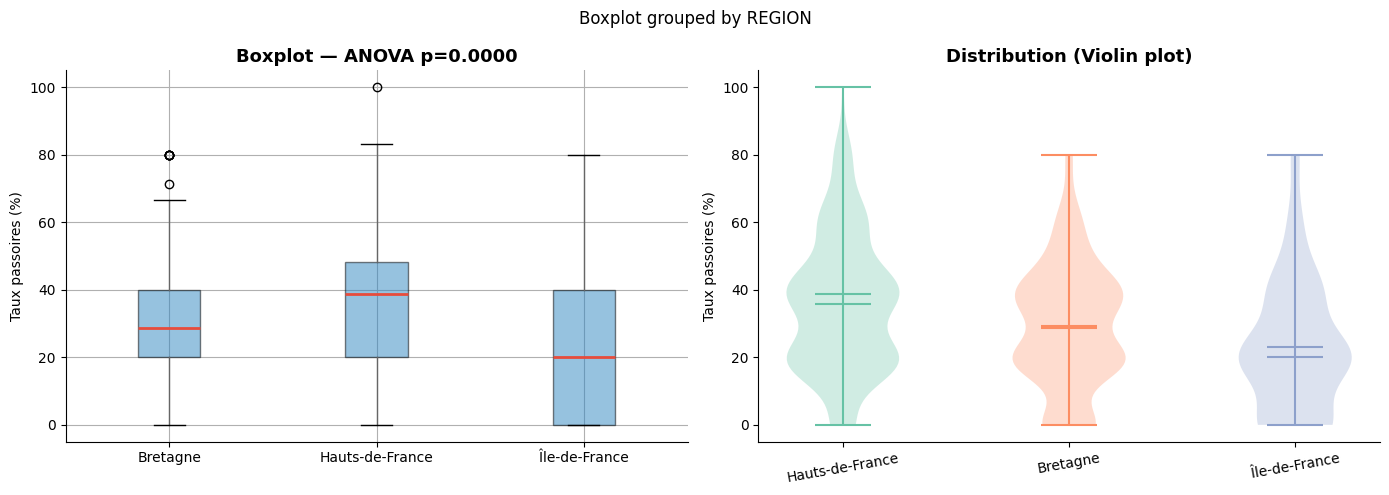


 Graphique → outputs/stats/anova_regions.png


In [4]:
print(' TEST ANOVA — Les taux de passoires diffèrent-ils significativement entre régions ?')
print('='*70)
print('\n   Hypothèses :')
print('   H0 : Les moyennes de taux de passoires sont identiques dans les 3 régions')
print('   H1 : Au moins une région a un taux significativement différent (α = 0.05)\n')

# Groupes par région
groupes_region = [
    g['TAUX_PASSOIRES'].dropna().values
    for _, g in df.groupby('REGION')
    if len(g['TAUX_PASSOIRES'].dropna()) > 10
]
noms_regions = [
    name for name, g in df.groupby('REGION')
    if len(g['TAUX_PASSOIRES'].dropna()) > 10
]

# ── Test ANOVA paramétrique ──────────────────────────────────
f_stat, p_val = f_oneway(*groupes_region)
print(f'   ANOVA paramétrique :')
print(f'   F-statistique : {f_stat:.4f}')
print(f'   p-value       : {p_val:.6f}')
print(f'   Conclusion    : {" H1 acceptée — différences significatives (p < 0.05)" if p_val < 0.05 else " H0 non rejetée — pas de différence significative"}')

# ── Test Kruskal-Wallis (non paramétrique, robuste) ──────────
h_stat, p_kruskal = kruskal(*groupes_region)
print(f'\n   Kruskal-Wallis (non paramétrique) :')
print(f'   H-statistique : {h_stat:.4f}')
print(f'   p-value       : {p_kruskal:.6f}')
print(f'   Conclusion    : {" Différences significatives confirmées" if p_kruskal < 0.05 else " Pas de différence significative"}')

# ── Statistiques par région ──────────────────────────────────
stats_region = df.groupby('REGION')['TAUX_PASSOIRES'].agg(
    N='count',
    Moyenne=lambda x: round(x.mean(), 2),
    Mediane=lambda x: round(x.median(), 2),
    EcartType=lambda x: round(x.std(), 2),
    Min='min',
    Max='max'
).round(2)
print('\n   Statistiques par région :')
display(stats_region)

# ── Visualisation ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Test ANOVA — Taux de Passoires par Région', fontsize=14, fontweight='bold')

# Boxplot
df.boxplot(column='TAUX_PASSOIRES', by='REGION', ax=axes[0],
           patch_artist=True,
           boxprops=dict(facecolor=C['blue'], alpha=0.5),
           medianprops=dict(color=C['red'], linewidth=2))
axes[0].set_title(f'Boxplot par région\n(ANOVA p={p_val:.4f})', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Taux passoires (%)')
plt.sca(axes[0]); plt.title(f'Boxplot — ANOVA p={p_val:.4f}')

# Violin plot
regions = df['REGION'].unique()
colors_reg = [C['blue'], C['red'], C['green']]
for i, (region, color) in enumerate(zip(regions, colors_reg)):
    data = df[df['REGION'] == region]['TAUX_PASSOIRES'].dropna()
    axes[1].violinplot([data], positions=[i], showmeans=True, showmedians=True)
axes[1].set_xticks(range(len(regions)))
axes[1].set_xticklabels(regions, rotation=10)
axes[1].set_ylabel('Taux passoires (%)')
axes[1].set_title('Distribution (Violin plot)', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/anova_regions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n Graphique → {OUTPUT_DIR}/anova_regions.png')

In [5]:
# ── Tests post-hoc : comparaisons par paires ─────────────────
print(' TESTS POST-HOC — Comparaisons par paires (Wilcoxon)')
print('='*55)
print('   (Quelles régions sont significativement différentes entre elles ?)\n')

from itertools import combinations
paires = list(combinations(noms_regions, 2))
resultats_paires = []

for r1, r2 in paires:
    g1 = df[df['REGION'] == r1]['TAUX_PASSOIRES'].dropna()
    g2 = df[df['REGION'] == r2]['TAUX_PASSOIRES'].dropna()
    _, pv = stats.mannwhitneyu(g1, g2, alternative='two-sided')
    resultats_paires.append({
        'Région 1': r1,
        'Région 2': r2,
        'Moy. R1':  round(g1.mean(), 2),
        'Moy. R2':  round(g2.mean(), 2),
        'p-value':  round(pv, 6),
        'Significatif (α=0.05)': ' Oui' if pv < 0.05 else ' Non'
    })
    print(f'   {r1} vs {r2} : p={pv:.6f} → {" Différence significative" if pv < 0.05 else " Pas de différence"}')

display(pd.DataFrame(resultats_paires))

 TESTS POST-HOC — Comparaisons par paires (Wilcoxon)
   (Quelles régions sont significativement différentes entre elles ?)

   Bretagne vs Hauts-de-France : p=0.001000 →  Différence significative
   Bretagne vs Île-de-France : p=0.003354 →  Différence significative
   Hauts-de-France vs Île-de-France : p=0.000002 →  Différence significative


,Région 1,Région 2,Moy. R1,Moy. R2,p-value,Significatif (α=0.05)
0,Bretagne,Hauts-de-France,29.32,35.70,0.001000,Oui
1,Bretagne,Île-de-France,29.32,22.98,0.003354,Oui
2,Hauts-de-France,Île-de-France,35.70,22.98,0.000002,Oui


---
## 4️⃣ Corrélations de Spearman

In [6]:
print(' CORRÉLATIONS DE SPEARMAN — Variables vs Taux Passoires')
print('='*60)
print('   (Spearman est robuste aux valeurs aberrantes — adapté à nos données)\n')

variables = {
    'REVENU_MEDIAN':           'Revenu médian (€)',
    'TAUX_PAUVRETE':           'Taux de pauvreté (%)',
    'POPULATION':              'Population',
    'ANNEE_CONSTRUCTION_MOY':  'Année construction moyenne',
    'CONSO_ENERGIE_MOY':       'Consommation énergie (kWh/m²/an)',
    'SURFACE_MOY':             'Surface moyenne (m²)',
    'NB_LOGEMENTS':            'Nb logements total',
}

resultats_corr = []
for col, label in variables.items():
    if col not in df.columns:
        continue
    sub = df[['TAUX_PASSOIRES', col]].dropna()
    if len(sub) < 10:
        continue
    rho, pv = spearmanr(sub['TAUX_PASSOIRES'], sub[col])
    intensite = (
        'Forte' if abs(rho) >= 0.5
        else 'Modérée' if abs(rho) >= 0.3
        else 'Faible'
    )
    sens = 'Négatif ↓' if rho < -0.05 else 'Positif ↑' if rho > 0.05 else 'Neutre ↔'
    resultats_corr.append({
        'Variable':          label,
        'Spearman rho':      round(rho, 4),
        'p-value':           round(pv, 6),
        'Significatif':      '✅' if pv < 0.05 else '❌',
        'Intensité':         intensite,
        'Sens':              sens,
        'N communes':        len(sub),
    })

df_corr = pd.DataFrame(resultats_corr).sort_values('Spearman rho')
display(df_corr.style
    .background_gradient(subset=['Spearman rho'], cmap='RdBu', vmin=-1, vmax=1)
    .format({'Spearman rho': '{:.4f}', 'p-value': '{:.6f}', 'N communes': '{:,}'}))

df_corr.to_csv(f'{OUTPUT_DIR}/correlations_spearman.csv', index=False, encoding='utf-8')
print(f'\n Résultats → {OUTPUT_DIR}/correlations_spearman.csv')

 CORRÉLATIONS DE SPEARMAN — Variables vs Taux Passoires
   (Spearman est robuste aux valeurs aberrantes — adapté à nos données)



,Variable,Spearman rho,p-value,Significatif,Intensité,Sens,N communes
3,Année construction moyenne,-0.7829,0.000000,✅,Forte,Négatif ↓,651
0,Revenu médian (€),-0.1076,0.017085,✅,Faible,Négatif ↓,491
2,Population,-0.0791,0.079754,❌,Faible,Négatif ↓,491
6,Nb logements total,0.0088,0.905884,❌,Faible,Neutre ↔,184
5,Surface moyenne (m²),0.0649,0.097866,❌,Faible,Positif ↑,651
1,Taux de pauvreté (%),0.0680,0.132286,❌,Faible,Positif ↑,491
4,Consommation énergie (kWh/m²/an),0.5826,0.000000,✅,Forte,Positif ↑,651



 Résultats → outputs/stats/correlations_spearman.csv


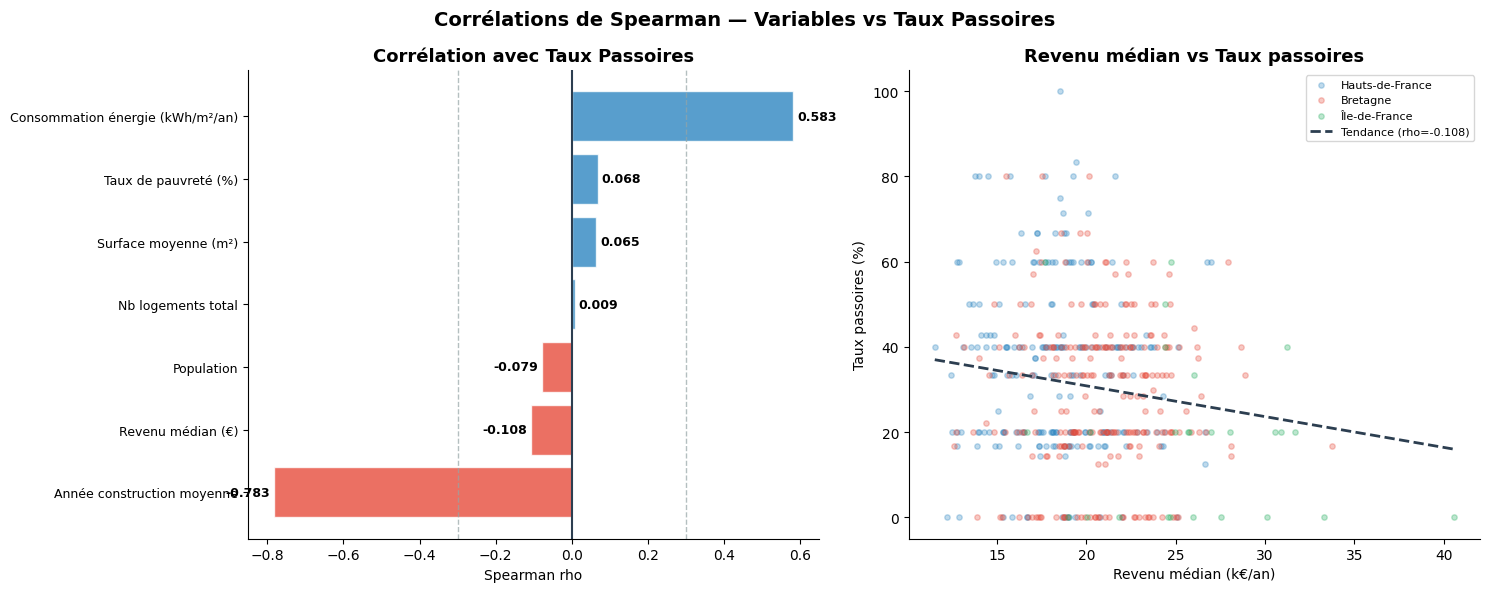

 Graphique → outputs/stats/correlations_spearman.png


In [7]:
# ── Graphique corrélations ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Corrélations de Spearman — Variables vs Taux Passoires', fontsize=14, fontweight='bold')

# Barres horizontales des rho
df_corr_plot = df_corr.sort_values('Spearman rho')
couleurs_bar = [C['red'] if r < 0 else C['blue'] for r in df_corr_plot['Spearman rho']]
bars = axes[0].barh(range(len(df_corr_plot)), df_corr_plot['Spearman rho'],
                    color=couleurs_bar, alpha=0.8, edgecolor='white')
axes[0].set_yticks(range(len(df_corr_plot)))
axes[0].set_yticklabels(df_corr_plot['Variable'], fontsize=9)
axes[0].axvline(x=0, color=C['dark'], linewidth=1.5)
axes[0].axvline(x=0.3,  color=C['gray'], linewidth=1, linestyle='--', alpha=0.7)
axes[0].axvline(x=-0.3, color=C['gray'], linewidth=1, linestyle='--', alpha=0.7)
axes[0].set_xlabel('Spearman rho')
axes[0].set_title('Corrélation avec Taux Passoires', fontweight='bold')
for bar, v in zip(bars, df_corr_plot['Spearman rho']):
    axes[0].text(v + 0.01 if v >= 0 else v - 0.01, bar.get_y() + bar.get_height()/2,
                 f'{v:.3f}', va='center', ha='left' if v >= 0 else 'right', fontsize=9, fontweight='bold')

# Scatter revenu vs taux passoires (relation la plus importante)
sub_rev = df[['TAUX_PASSOIRES','REVENU_MEDIAN','REGION']].dropna()
for region, color in zip(sub_rev['REGION'].unique(), [C['blue'], C['red'], C['green']]):
    grp = sub_rev[sub_rev['REGION'] == region]
    axes[1].scatter(grp['REVENU_MEDIAN']/1000, grp['TAUX_PASSOIRES'],
                    alpha=0.3, s=15, color=color, label=region)
# Droite de régression
z = np.polyfit(sub_rev['REVENU_MEDIAN'], sub_rev['TAUX_PASSOIRES'], 1)
x_line = np.linspace(sub_rev['REVENU_MEDIAN'].min(), sub_rev['REVENU_MEDIAN'].max(), 100)
rho_rev = df_corr[df_corr['Variable'] == 'Revenu médian (€)']['Spearman rho'].values
rho_label = f'rho={rho_rev[0]:.3f}' if len(rho_rev) > 0 else ''
axes[1].plot(x_line/1000, np.poly1d(z)(x_line), color=C['dark'],
             linewidth=2, linestyle='--', label=f'Tendance ({rho_label})')
axes[1].set_xlabel('Revenu médian (k€/an)')
axes[1].set_ylabel('Taux passoires (%)')
axes[1].set_title('Revenu médian vs Taux passoires', fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/correlations_spearman.png', dpi=150, bbox_inches='tight')
plt.show()
print(f' Graphique → {OUTPUT_DIR}/correlations_spearman.png')

---
## 5️⃣ Analyse par période de construction

 ANALYSE PAR PÉRIODE DE CONSTRUCTION

   Taux de passoires moyen par période de construction :


,PERIODE,N,Moyenne,Mediane,EcartType
0,Avant 1945,1,80.00,80.0,NaN
1,1945–1960,50,61.39,60.0,14.80
2,1960–1975,269,40.05,40.0,14.74
3,1975–1990,297,19.53,20.0,13.39
4,1990–2000,31,7.99,0.0,10.93
5,2000–2010,3,0.00,0.0,0.00



   ANOVA entre périodes : F=210.932, p=0.000000
   →  Les périodes influencent significativement le taux de passoires


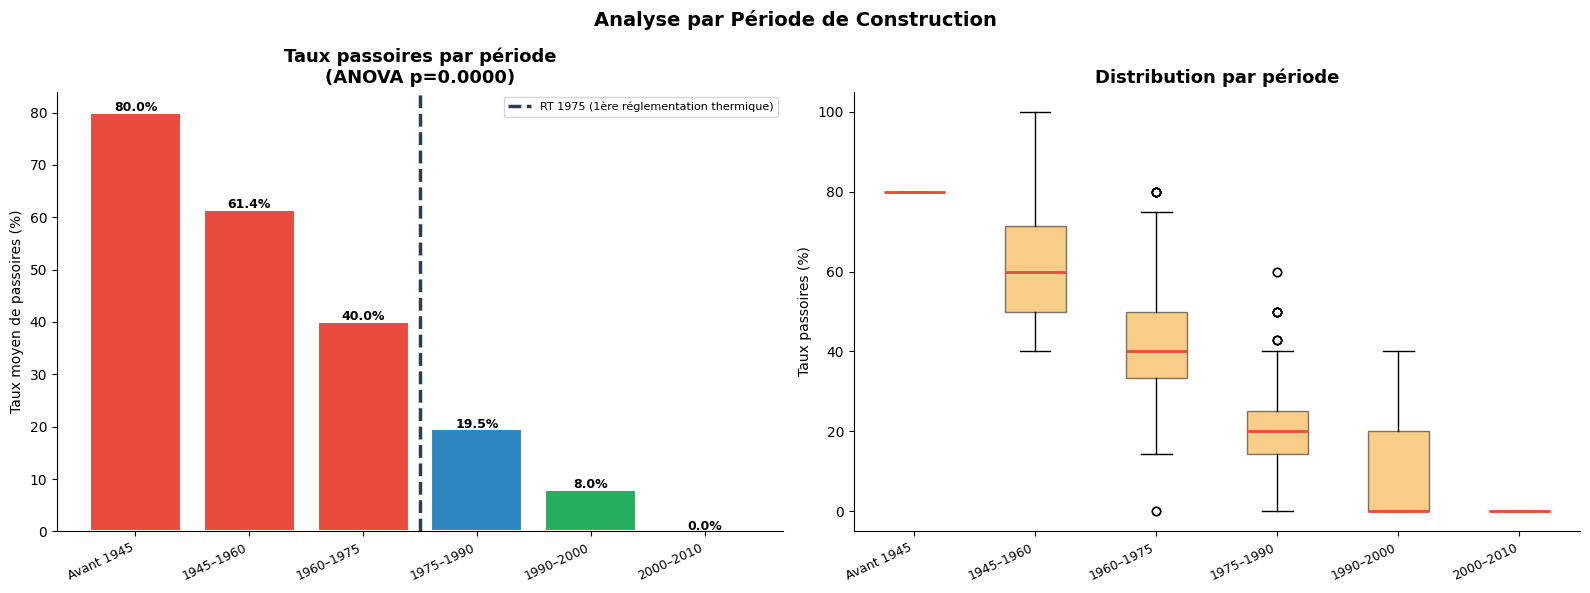


 Graphique → outputs/stats/analyse_periode_construction.png
 Données   → outputs/stats/stats_periode_construction.csv


In [8]:
print(' ANALYSE PAR PÉRIODE DE CONSTRUCTION')
print('='*55)

df_ann = df.dropna(subset=['ANNEE_CONSTRUCTION_MOY', 'TAUX_PASSOIRES']).copy()

# Catégories par période
bins   = [0, 1945, 1960, 1975, 1990, 2000, 2010, 2026]
labels = ['Avant 1945','1945–1960','1960–1975','1975–1990',
          '1990–2000','2000–2010','Après 2010']
df_ann['PERIODE'] = pd.cut(df_ann['ANNEE_CONSTRUCTION_MOY'],
                            bins=bins, labels=labels, include_lowest=True)

# Statistiques par période
stats_periode = df_ann.groupby('PERIODE', observed=True)['TAUX_PASSOIRES'].agg(
    N='count',
    Moyenne=lambda x: round(x.mean(), 2),
    Mediane=lambda x: round(x.median(), 2),
    EcartType=lambda x: round(x.std(), 2),
).reset_index()

print('\n   Taux de passoires moyen par période de construction :')
display(stats_periode)

# Test ANOVA entre périodes
groupes_periodes = [
    g['TAUX_PASSOIRES'].values
    for _, g in df_ann.groupby('PERIODE', observed=True)
    if len(g) > 5
]
f_p, p_p = f_oneway(*groupes_periodes)
print(f'\n   ANOVA entre périodes : F={f_p:.3f}, p={p_p:.6f}')
print(f'   → {" Les périodes influencent significativement le taux de passoires" if p_p < 0.05 else " Pas de différence significative"}')

# ── Visualisation ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Analyse par Période de Construction', fontsize=14, fontweight='bold')

# Histogramme taux moyen par période
couleurs_p = [
    C['red'] if v > 30 else C['orange'] if v > 20 else C['blue'] if v > 10 else C['green']
    for v in stats_periode['Moyenne']
]
bars_p = axes[0].bar(range(len(stats_periode)), stats_periode['Moyenne'],
                     color=couleurs_p, edgecolor='white', linewidth=1.5)
# Ligne réglementation thermique 1975
idx_1975 = labels.index('1975–1990')
axes[0].axvline(x=idx_1975 - 0.5, color=C['dark'], linewidth=2.5,
                linestyle='--', label='RT 1975 (1ère réglementation thermique)')
axes[0].set_xticks(range(len(stats_periode)))
axes[0].set_xticklabels(stats_periode['PERIODE'], rotation=25, ha='right', fontsize=9)
axes[0].set_ylabel('Taux moyen de passoires (%)')
axes[0].set_title(f'Taux passoires par période\n(ANOVA p={p_p:.4f})', fontweight='bold')
axes[0].legend(fontsize=8)
for bar, v in zip(bars_p, stats_periode['Moyenne']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)

# Boxplot par période
groupes_box = [
    df_ann[df_ann['PERIODE'] == p]['TAUX_PASSOIRES'].dropna().values
    for p in labels
]
groupes_box = [g for g in groupes_box if len(g) > 0]
bp = axes[1].boxplot(groupes_box, patch_artist=True,
                     boxprops=dict(facecolor=C['orange'], alpha=0.5),
                     medianprops=dict(color=C['red'], linewidth=2))
axes[1].set_xticklabels(
    [l for l, g in zip(labels, [df_ann[df_ann['PERIODE']==p]['TAUX_PASSOIRES'].dropna().values for p in labels]) if len(g)>0],
    rotation=25, ha='right', fontsize=9)
axes[1].set_ylabel('Taux passoires (%)')
axes[1].set_title('Distribution par période', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/analyse_periode_construction.png', dpi=150, bbox_inches='tight')
plt.show()

stats_periode.to_csv(f'{OUTPUT_DIR}/stats_periode_construction.csv', index=False, encoding='utf-8')
print(f'\n Graphique → {OUTPUT_DIR}/analyse_periode_construction.png')
print(f' Données   → {OUTPUT_DIR}/stats_periode_construction.csv')

In [9]:
# ── Analyse croisée : période × région ───────────────────────
print(' ANALYSE CROISÉE — Période de construction × Région')
print('='*55)

pivot_periode = df_ann.groupby(['REGION','PERIODE'], observed=True)['TAUX_PASSOIRES'].mean().round(2)
pivot_periode = pivot_periode.unstack(level='PERIODE')
print('\n   Taux moyen de passoires (%) par région et période :')
display(pivot_periode.style
    .background_gradient(cmap='RdYlGn_r', axis=None)
    .format('{:.1f}%'))

 ANALYSE CROISÉE — Période de construction × Région

   Taux moyen de passoires (%) par région et période :


PERIODE,Avant 1945,1945–1960,1960–1975,1975–1990,1990–2000,2000–2010
REGION,,,,,,
Bretagne,nan%,58.4%,39.3%,20.2%,8.9%,0.0%
Hauts-de-France,80.0%,62.6%,40.5%,21.2%,11.8%,nan%
Île-de-France,nan%,70.0%,41.7%,14.8%,2.5%,0.0%


---
## 6️⃣ Export Top 20 communes prioritaires

 TOP 20 COMMUNES PRIORITAIRES POUR LA RÉNOVATION


,CODGEO,NOM_COMMUNE,REGION,DEP,TAUX_PASSOIRES,NB_PASSOIRES,REVENU_MEDIAN,TAUX_PAUVRETE,PASSOIRES_POUR_1000_HAB,POPULATION,SCORE_PRIORITE,CATEGORIE_PRIORITE,RANG_PRIORITE
1,02225,Courchamps,Hauts-de-France,2.000000,80.0%,4,"13,758 €",26.5%,48.780000,82,0.6857,Haute,74
2,62269,Diéval,Hauts-de-France,62.000000,100.0%,5,"18,504 €",25.8%,7.050000,709,0.6720,Haute,115
3,02118,Braye,Hauts-de-France,2.000000,80.0%,4,"15,737 €",27.1%,31.010000,129,0.6463,Moyenne,210
4,62144,Boiry-Becquerelle,Hauts-de-France,62.000000,80.0%,4,"14,484 €",33.8%,8.370000,478,0.6416,Moyenne,230
5,59090,Bondues,Hauts-de-France,59.000000,80.0%,4,"13,983 €",30.1%,0.410000,"9,747",0.6407,Moyenne,235
6,22110,Lanmérin,Bretagne,22.000000,80.0%,4,"15,498 €",32.7%,6.960000,575,0.6282,Moyenne,268
7,02278,Éparcy,Hauts-de-France,2.000000,66.7%,4,"18,246 €",26.9%,105.260000,38,0.6278,Moyenne,269
8,22369,Trémeur,Bretagne,22.000000,80.0%,4,"17,503 €",25.3%,4.940000,809,0.6023,Moyenne,333
9,02111,Brancourt-en-Laonnois,Hauts-de-France,2.000000,80.0%,4,"17,702 €",25.8%,5.700000,702,0.6005,Moyenne,336
10,60398,Le Mesnil-en-Thelle,Hauts-de-France,60.000000,83.3%,5,"19,410 €",21.4%,2.050000,"2,439",0.5901,Moyenne,362


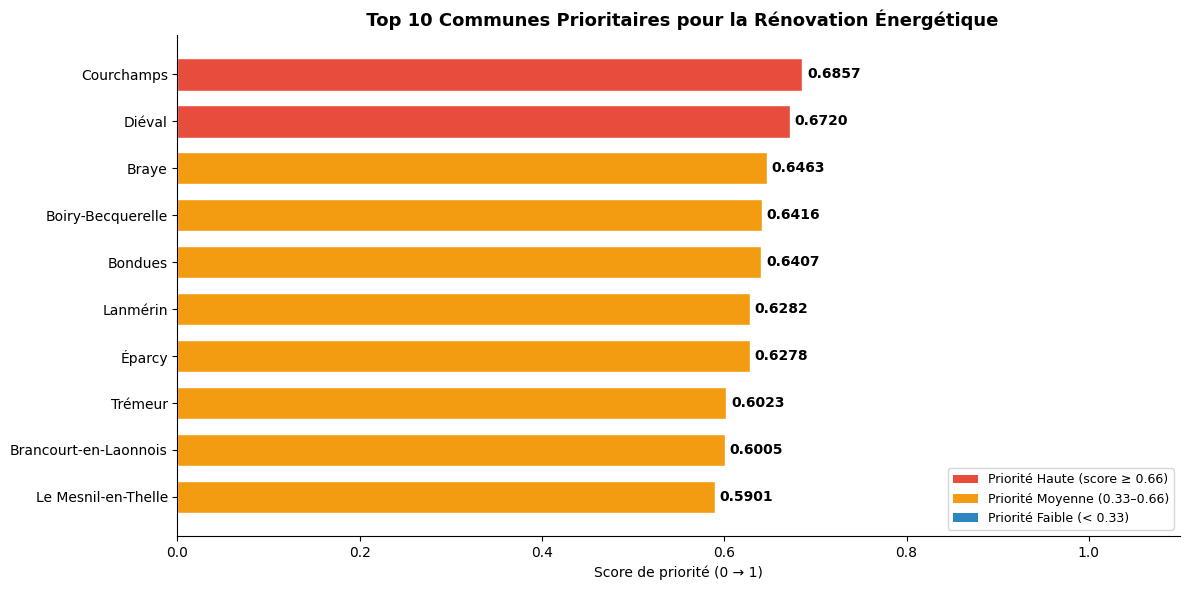


 Top 20 exporté → outputs/stats/top20_communes_prioritaires.csv
 Graphique      → outputs/stats/top10_communes_prioritaires.png



In [13]:
print(' TOP 20 COMMUNES PRIORITAIRES POUR LA RÉNOVATION')
print('='*55)

cols_top = [c for c in [
    'CODGEO','NOM_COMMUNE','REGION','DEP',
    'TAUX_PASSOIRES','NB_PASSOIRES',
    'REVENU_MEDIAN','TAUX_PAUVRETE',
    'PASSOIRES_POUR_1000_HAB','POPULATION',
    'SCORE_PRIORITE','CATEGORIE_PRIORITE','RANG_PRIORITE'
] if c in df.columns]

top20 = (df.sort_values('SCORE_PRIORITE', ascending=False)
           .head(20)[cols_top]
           .reset_index(drop=True))
top20.index = top20.index + 1  # Rang commence à 1

display(top20.style
    .background_gradient(subset=['SCORE_PRIORITE'], cmap='Reds')
    .background_gradient(subset=['TAUX_PASSOIRES'], cmap='Oranges')
    .format({
        'TAUX_PASSOIRES':   '{:.1f}%',
        'REVENU_MEDIAN':    '{:,.0f} €',
        'TAUX_PAUVRETE':    '{:.1f}%',
        'SCORE_PRIORITE':   '{:.4f}',
        'POPULATION':       '{:,.0f}',
        'NB_PASSOIRES':     '{:,.0f}',
    }))

# ── Graphique Top 10 ─────────────────────────────────────────
top10 = top20.head(10).copy()
labels_top = top10['NOM_COMMUNE'].fillna(top10['CODGEO']) if 'NOM_COMMUNE' in top10.columns else top10['CODGEO']

fig, ax = plt.subplots(figsize=(12, 6))
couleurs_top = [
    C['red'] if v >= 0.66 else C['orange'] if v >= 0.33 else C['blue']
    for v in top10['SCORE_PRIORITE']
]
bars_top = ax.barh(range(len(top10)), top10['SCORE_PRIORITE'],
                   color=couleurs_top, edgecolor='white', height=0.7)
ax.set_yticks(range(len(top10)))
ax.set_yticklabels(labels_top.values, fontsize=10)
ax.set_xlabel('Score de priorité (0 → 1)')
ax.set_title(' Top 10 Communes Prioritaires pour la Rénovation Énergétique',
             fontsize=13, fontweight='bold')
for bar, v in zip(bars_top, top10['SCORE_PRIORITE']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center', fontweight='bold', fontsize=10)
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
# Légende catégories
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=C['red'],    label='Priorité Haute (score ≥ 0.66)'),
    Patch(facecolor=C['orange'], label='Priorité Moyenne (0.33–0.66)'),
    Patch(facecolor=C['blue'],   label='Priorité Faible (< 0.33)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/top10_communes_prioritaires.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Exports ──────────────────────────────────────────────────
top20.to_csv(f'{OUTPUT_DIR}/top20_communes_prioritaires.csv', index=True, encoding='utf-8')
print(f'\n Top 20 exporté → {OUTPUT_DIR}/top20_communes_prioritaires.csv')
print(f' Graphique      → {OUTPUT_DIR}/top10_communes_prioritaires.png')
print()


In [11]:
# ── Répartition catégories priorité ─────────────────────────
print('\n Répartition des communes par catégorie de priorité :')
if 'CATEGORIE_PRIORITE' in df.columns:
    cat_counts = df['CATEGORIE_PRIORITE'].value_counts()
    for cat, n in cat_counts.items():
        pct = n/len(df)*100
        barre = '█' * int(pct/2)
        print(f'   {str(cat):<25} : {n:>5,} communes ({pct:>5.1f}%) {barre}')


 Répartition des communes par catégorie de priorité :
   Moyenne                   :   328 communes ( 50.4%) █████████████████████████
   Faible                    :   161 communes ( 24.7%) ████████████
   Haute                     :     2 communes (  0.3%) 


---
## 7️⃣ Synthèse & Conclusions

In [12]:
print('='*65)
print(' SYNTHÈSE ANALYTIQUE — FRPT-6 Analyse Statistique')
print('='*65)

print('\n RÉPONSE À LA PROBLÉMATIQUE :')
print('   Quelles communes prioriser pour la rénovation énergétique ?')
print('   → Voir Top 20 exporté dans outputs/stats/top20_communes_prioritaires.csv')

print('\n RÉSULTATS STATISTIQUES CLÉS :')

# Résultat ANOVA
print(f'\n   1. ANOVA inter-régions :')
print(f'      → F={f_stat:.3f}, p={p_val:.6f}')
print(f'      → Les 3 régions ont des taux de passoires {"significativement différents" if p_val < 0.05 else "similaires"}')

# Résultat corrélation revenu
corr_rev = df_corr[df_corr['Variable'].str.contains('Revenu')]
if len(corr_rev) > 0:
    rho_r = corr_rev['Spearman rho'].values[0]
    print(f'\n   2. Corrélation Revenu ↔ Passoires :')
    print(f'      → rho = {rho_r:.4f} (corrélation {"négative" if rho_r < 0 else "positive"})')
    print(f'      → Plus le revenu est faible, plus il y a de passoires thermiques')

# Résultat période construction
periode_max = stats_periode.loc[stats_periode['Moyenne'].idxmax(), 'PERIODE']
taux_max_p  = stats_periode['Moyenne'].max()
print(f'\n   3. Période de construction la plus problématique :')
print(f'      → Période {periode_max} : {taux_max_p:.1f}% de passoires en moyenne')
print(f'      → Les logements construits avant la RT 1975 concentrent le plus de passoires')

print(f'\n Fichiers produits dans outputs/stats/ :')
for f_name in sorted(os.listdir(OUTPUT_DIR)):
    taille = os.path.getsize(f'{OUTPUT_DIR}/{f_name}') / 1024
    print(f'    {f_name:<50} {taille:.1f} Ko')



 SYNTHÈSE ANALYTIQUE — FRPT-6 Analyse Statistique

 RÉPONSE À LA PROBLÉMATIQUE :
   Quelles communes prioriser pour la rénovation énergétique ?
   → Voir Top 20 exporté dans outputs/stats/top20_communes_prioritaires.csv

 RÉSULTATS STATISTIQUES CLÉS :

   1. ANOVA inter-régions :
      → F=15.819, p=0.000000
      → Les 3 régions ont des taux de passoires significativement différents

   2. Corrélation Revenu ↔ Passoires :
      → rho = -0.1076 (corrélation négative)
      → Plus le revenu est faible, plus il y a de passoires thermiques

   3. Période de construction la plus problématique :
      → Période Avant 1945 : 80.0% de passoires en moyenne
      → Les logements construits avant la RT 1975 concentrent le plus de passoires

 Fichiers produits dans outputs/stats/ :
    analyse_periode_construction.png                   91.6 Ko
    anova_regions.png                                  74.1 Ko
    correlations_spearman.csv                          0.5 Ko
    correlations_spearman.png 